In [90]:
import numpy as np
from mini_nn.layers import Linear
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# --- create x (input matrix) with 500 observations and 10,000 features ---
x = np.random.normal(0, 1, size=(500,10000))

In [84]:
# --- set a linear layer with 4 neurons and random initialization ---
linear = Linear(in_features = x.shape[1],
                out_features = 4)

# --- set a linear layer with 4 neurons and he_normal initialization ---
linear_normal = Linear(in_features = x.shape[1],
                out_features = 4,
                initialize='he_normal')

# --- set a linear layer with 4 neurons and he_uniform initialization ---
linear_uniform = Linear(in_features = x.shape[1],
                out_features = 4,
                initialize='he_uniform')

In [ ]:
weights = linear.weight
print(f'Linear layer total shape: {weights.shape}')
print(f'Linear layer input size: {weights.shape[0]}')
print(f'Linear layer output size: {weights.shape[1]}')
print(f'Linear layer weights mean={np.mean(weights.reshape(-1)):.4f}')
print(f'Linear layer weights std={np.std(weights.reshape(-1)):.4f}')
print('='*60)

henormal_weights = linear_normal.weight
print(f'He normal linear layer total shape: {henormal_weights.shape}')
print(f'He normal linear layer input size: {henormal_weights.shape[0]}')
print(f'He normal linear layer output size: {henormal_weights.shape[1]}')
print(f'He normal linear layer weights mean={np.mean(henormal_weights.reshape(-1)):.4f}')
print(f'He normal linear layer weights std={np.std(henormal_weights.reshape(-1)):.4f}')
print('='*60)

heuniform_weights = linear_uniform.weight
print(f'He uniform linear layer total shape: {heuniform_weights.shape}')
print(f'He uniform linear layer input size: {heuniform_weights.shape[0]}')
print(f'He uniform linear layer output size: {heuniform_weights.shape[1]}')
print(f'He uniform linear layer weights mean={np.mean(heuniform_weights.reshape(-1)):.4f}')
print(f'He uniform linear layer weights std={np.std(heuniform_weights.reshape(-1)):.4f}')


Linear layer total shape: (10000, 4)
Linear layer input size: 10000
Linear layer output size: 4
Linear layer weights mean=-0.0000
Linear layer weights std=0.0100
He normal linear layer total shape: (10000, 4)
He normal linear layer input size: 10000
He normal linear layer output size: 4
He normal linear layer weights mean=-0.0000
He normal linear layer weights std=0.0142
He uniform linear layer total shape: (10000, 4)
He uniform linear layer input size: 10000
He uniform linear layer output size: 4
He uniform linear layer weights mean=-0.0000
He uniform linear layer weights std=0.0142


In [97]:
expected_std = np.sqrt(2 / x.shape[1])
uniform_limit = np.sqrt(6 / x.shape[1])

print(f'Expected He std: {expected_std:.6f}')
print(f'He Normal actual std: {henormal_weights.std():.6f}')
print(f'He Uniform actual std: {heuniform_weights.std():.6f}')
print()
print(f'Expected uniform limits: ±{uniform_limit:.6f}')
print(f'Actual uniform min: {heuniform_weights.min():.6f}')
print(f'Actual uniform max: {heuniform_weights.max():.6f}')

Expected He std: 0.014142
He Normal actual std: 0.014170
He Uniform actual std: 0.014162

Expected uniform limits: ±0.024495
Actual uniform min: -0.024494
Actual uniform max: 0.024494


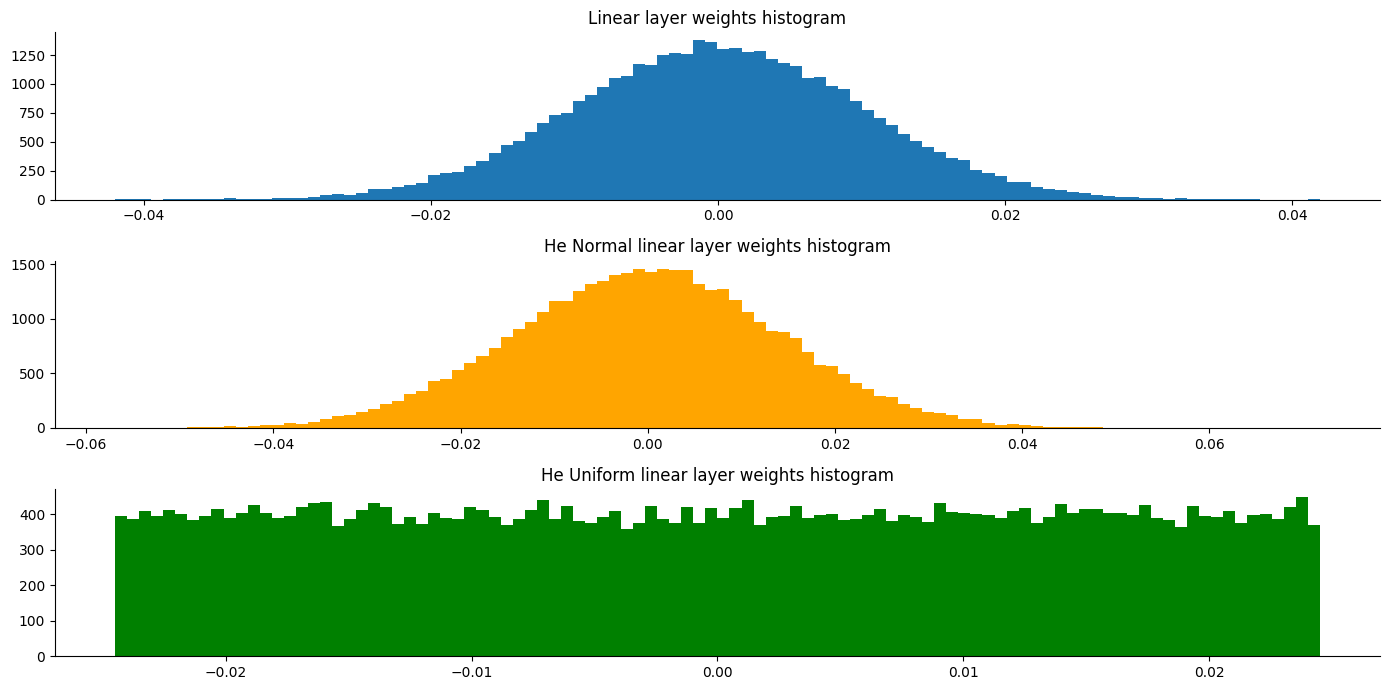

In [ ]:
# --- plot comparison ---

fig, ax = plt.subplots(3, 1, figsize=(14,7))

# --- linear layer weights hist ---
ax[0].hist(weights.reshape(-1), bins=100)
ax[0].set_title('Linear layer weights histogram')

# ---linear layer with he normal initialization hist ---
ax[1].hist(henormal_weights.reshape(-1), bins=100,
           color='orange')
ax[1].set_title('He Normal linear layer weights histogram')

# ---linear layer with he uniform initialization hist ---
ax[2].hist(heuniform_weights.reshape(-1), bins=100,
           color='g')
ax[2].set_title('He Uniform linear layer weights histogram')

sns.despine()
plt.tight_layout()
plt.show()